In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn ipykernel


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip insatall shap

ERROR: unknown command "insatall" - maybe you meant "install"



In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')
import pickle

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("heartdisease.csv")
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         29891 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-null  object 
 9   Stress_Level           50000 non-null  object 
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int64  
 15  Sy

In [6]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [7]:
df.describe()

,Age,Weight,Height,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.46406,84.547520,174.460000,28.984284,0.299620,0.199260,0.251660,0.400500,0.099280,139.299580,89.528800,84.449560,124.493020,224.556360,0.463460
std,14.43809,20.213257,14.420379,6.367494,0.458096,0.399448,0.433971,0.490005,0.299041,23.083544,17.258063,14.491325,31.691507,43.157467,0.498668
min,30.00000,50.000000,150.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,60.000000,60.000000,70.000000,150.000000,0.000000
25%,42.00000,67.000000,162.000000,23.500000,0.000000,0.000000,0.000000,0.000000,0.000000,119.000000,75.000000,72.000000,97.000000,187.000000,0.000000
50%,54.00000,85.000000,174.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.000000,90.000000,85.000000,125.000000,225.000000,0.000000
75%,67.00000,102.000000,187.000000,34.500000,1.000000,0.000000,1.000000,1.000000,0.000000,159.000000,104.000000,97.000000,152.000000,262.000000,1.000000
max,79.00000,119.000000,199.000000,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,109.000000,179.000000,299.000000,1.000000


In [8]:
df.isnull().sum()

Age                          0
Gender                       0
Weight                       0
Height                       0
BMI                          0
Smoking                      0
Alcohol_Intake           20109
Physical_Activity            0
Diet                         0
Stress_Level                 0
Hypertension                 0
Diabetes                     0
Hyperlipidemia               0
Family_History               0
Previous_Heart_Attack        0
Systolic_BP                  0
Diastolic_BP                 0
Heart_Rate                   0
Blood_Sugar_Fasting          0
Cholesterol_Total            0
Heart_Disease                0
dtype: int64

! Data Cleaning & Preprocessing

In [9]:
# Fill categorical missing values with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)
   
# Fill numerical missing values with median
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)   
    
df.isnull().sum()    

Age                      0
Gender                   0
Weight                   0
Height                   0
BMI                      0
Smoking                  0
Alcohol_Intake           0
Physical_Activity        0
Diet                     0
Stress_Level             0
Hypertension             0
Diabetes                 0
Hyperlipidemia           0
Family_History           0
Previous_Heart_Attack    0
Systolic_BP              0
Diastolic_BP             0
Heart_Rate               0
Blood_Sugar_Fasting      0
Cholesterol_Total        0
Heart_Disease            0
dtype: int64

! lable encoder


In [10]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    

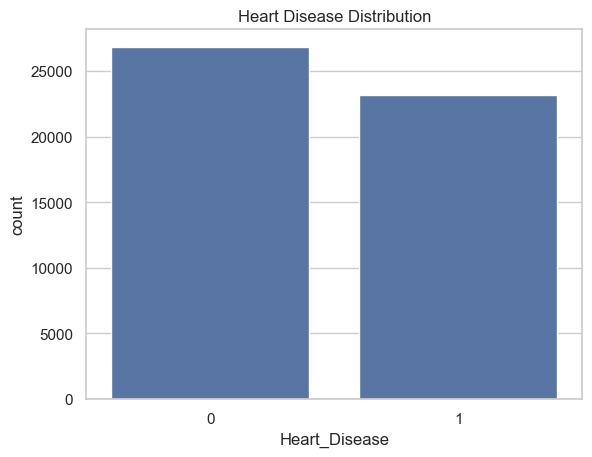

In [11]:
# EDA analysis and visualization code here

sns.countplot(x="Heart_Disease", data=df)
plt.title("Heart Disease Distribution")
plt.show()


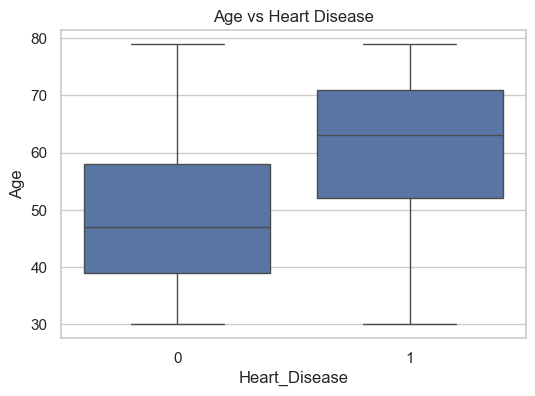

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Heart_Disease", y="Age", data=df)
plt.title("Age vs Heart Disease")
plt.show()

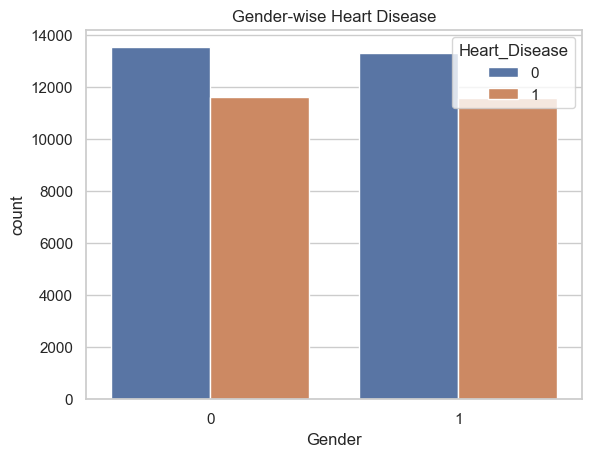

In [13]:
sns.countplot(x="Gender", hue="Heart_Disease", data=df)
plt.title("Gender-wise Heart Disease")
plt.show()

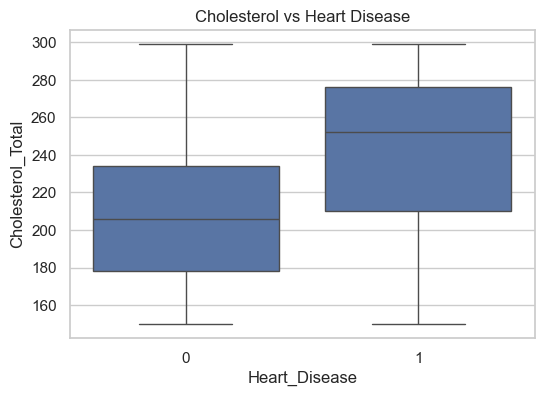

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Heart_Disease", y="Cholesterol_Total", data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

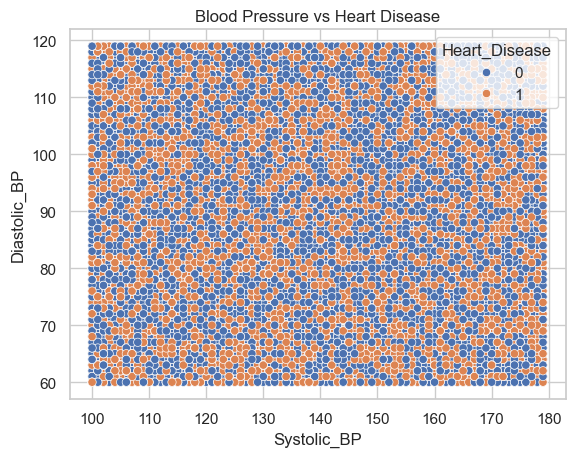

In [15]:
sns.scatterplot(
    x="Systolic_BP", y="Diastolic_BP",
    hue="Heart_Disease", data=df
)
plt.title("Blood Pressure vs Heart Disease")
plt.show()

! Data Analytics KPIs & Insights

In [16]:
total_patients = len(df)
heart_disease_rate = df["Heart_Disease"].mean() * 100
avg_chol = df["Cholesterol_Total"].mean()
avg_bp = df["Systolic_BP"].mean()

total_patients, heart_disease_rate, avg_chol, avg_bp

(50000, np.float64(46.346), np.float64(224.55636), np.float64(139.29958))

In [17]:
# feature engineering and scaling
X = df.drop("Heart_Disease", axis=1)
y = df["Heart_Disease"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total
0,48,1,78,157,26.4,2,1,2,1,2,0,0,1,1,0,104,99,71,165,200
1,35,0,73,163,33.0,2,1,0,0,0,1,0,1,1,0,111,72,60,145,206
2,79,0,88,152,32.3,2,1,1,0,2,0,0,0,1,0,116,102,78,148,208
3,75,1,106,171,37.4,2,2,1,0,1,0,0,1,0,0,171,92,109,105,290
4,34,0,65,191,18.5,0,1,2,1,1,1,1,0,0,0,164,67,108,116,220


In [18]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)   

In [19]:
# machine learning model training and evaluation

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

In [20]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [21]:
# model evaluation 

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"----- {name} -----")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print()

evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

----- Logistic Regression -----
Accuracy: 0.9238
Precision: 0.9179797107705591
Recall: 0.9175836030204962
F1: 0.9177816141562365
ROC-AUC: 0.9822386698717466

----- Random Forest -----
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0



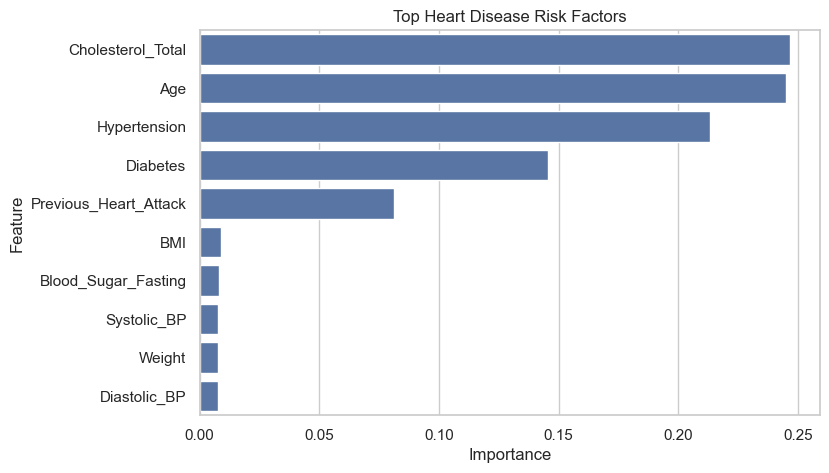

In [22]:
# Explainable AI
fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=fi.head(10))
plt.title("Top Heart Disease Risk Factors")
plt.show()


In [23]:
#SHAP Explainability
import sys
sys.executable


'c:\\Users\\Lenovo\\Heart disease\\.venv\\Scripts\\python.exe'

In [24]:
!{sys.executable} -m pip install shap

'c:\Users\Lenovo\Heart' is not recognized as an internal or external command,
operable program or batch file.


In [25]:
%pip install shap
# 
import shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import shap

100%|===================| 19986/20000 [22:25<00:00]        

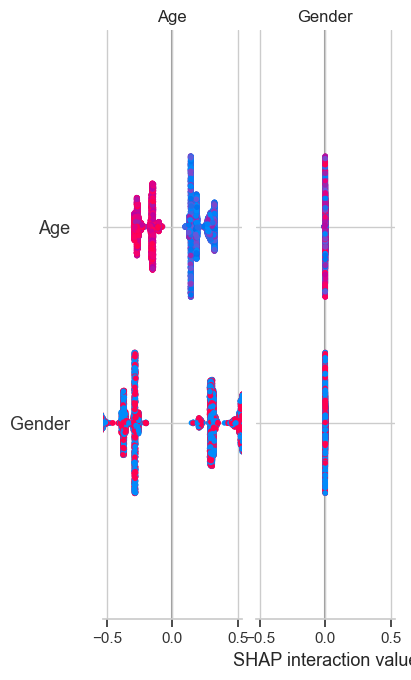

In [27]:
# Ensure the RandomForest model is fitted (has estimators_)
if not hasattr(rf, "estimators_"):
	rf.fit(X_train, y_train)

# convert scaled arrays back to DataFrames so SHAP can use feature names
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Create TreeExplainer. Some SHAP versions don't accept check_additivity or model_output kwargs,
# so try the common signature and fall back if needed.
try:
	explainer = shap.TreeExplainer(rf, data=X_train_df, model_output="probability")
except TypeError:
	explainer = shap.TreeExplainer(rf, data=X_train_df)

# compute SHAP values (handle both older and newer SHAP APIs)
if hasattr(explainer, "shap_values"):
	shap_values = explainer.shap_values(X_test_df)
else:
	# newer SHAP returns an Explanation object when called
	shap_values = explainer(X_test_df).values

# For binary classifiers shap_values is usually a list [class_0, class_1]; plot the positive class contributions
if isinstance(shap_values, list):
	shap_to_plot = shap_values[1]
else:
	shap_to_plot = shap_values

# summary plot (works with array-like SHAP values)
shap.summary_plot(shap_to_plot, X_test_df)

! RISK CLASSIFICATION SYSTEM

In [28]:
def risk_category(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

risk_levels = [risk_category(p) for p in rf_prob]
pd.Series(risk_levels).value_counts()

Low Risk     5365
High Risk    4635
Name: count, dtype: int64

In [29]:
recommendations = {
    "Low Risk": "Maintain healthy lifestyle and regular checkups",
    "Medium Risk": "Diet control, exercise, and medical monitoring",
    "High Risk": "Immediate clinical intervention and cardiology consult"
}

pd.Series(risk_levels).map(recommendations).value_counts()


Maintain healthy lifestyle and regular checkups           5365
Immediate clinical intervention and cardiology consult    4635
Name: count, dtype: int64

In [30]:
pickle.dump(rf, open("heart_disease_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
